<a href="https://colab.research.google.com/github/Manha-tech/BikeBuddy-ML-Project-/blob/main/bikebuddy_resale.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

In [4]:
uploaded=files.upload()


Saving ml_project_clean.csv to ml_project_clean.csv


In [6]:
file_name=list(uploaded.keys())[0]
df=pd.read_csv(file_name)
print("Dataset loaded successfully")

Dataset loaded successfully


In [13]:
print("First 5 rows")
display(df.head())

print("dataset shape")
print(df.shape)

print(df.columns.tolist())

df.info()

print("Missing values")
print(df.isnull().sum)





First 5 rows


,Brand,Model,KM_Driven,Year,Price,Owner
0,BMW,R1200GS,50000,2017,1100000,3rd owner
1,BMW,g310gs,26715,2022,320000,1st owner
2,BMW,g310rr,7863,2024,315000,1st owner
3,Bajaj,CT100,24000,2021,34000,1st owner
4,Bajaj,Discover110,87000,2006,13000,2nd owner


dataset shape
(293, 6)
['Brand', 'Model', 'KM_Driven', 'Year', 'Price', 'Owner']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Brand      293 non-null    object
 1   Model      293 non-null    object
 2   KM_Driven  293 non-null    int64 
 3   Year       293 non-null    int64 
 4   Price      293 non-null    int64 
 5   Owner      293 non-null    object
dtypes: int64(3), object(3)
memory usage: 13.9+ KB
Missing values
<bound method DataFrame.sum of      Brand  Model  KM_Driven   Year  Price  Owner
0    False  False      False  False  False  False
1    False  False      False  False  False  False
2    False  False      False  False  False  False
3    False  False      False  False  False  False
4    False  False      False  False  False  False
..     ...    ...        ...    ...    ...    ...
288  False  False      False  False  False  False
289  F

In [15]:
target_column="Price"
if target_column not in df.columns:
  raise ValueError("Target column not found")
print("Target column:",target_column)

Target column: Price


In [17]:
df[target_column]=pd.to_numeric(
    df[target_column].astype(str).str.replace(
        r"[₹,\s]","", regex=True
    ),
    errors="coerce"
)

In [20]:
df=df.dropna(subset=[target_column])
df=df.reset_index(drop=True)
print("Dataset shape after cleaning:",df.shape)

Dataset shape after cleaning: (293, 6)


In [25]:
X=df.drop(columns=[target_column])
y=df[target_column]


In [26]:
print("Input features:")
print(X.columns.tolist())

print("\n target:")
print(y.name)

Input features:
['Brand', 'Model', 'KM_Driven', 'Year', 'Owner']

 target:
Price


In [28]:
numerical_columns=X.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

categorical_columns=X.select_dtypes(
    include=["object","category","bool"]
).columns.tolist()

In [29]:
print("Numerical columns:")
print(numerical_columns)

print("\n Categorical_columns")
print(categorical_columns)

Numerical columns:
['KM_Driven', 'Year']

 Categorical_columns
['Brand', 'Model', 'Owner']


In [31]:
numerical_transformer=Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

In [32]:
categorical_transformer=Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [35]:
preprocessor=ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)

In [36]:
X_train, X_test, y_train, y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (234, 5)
Testing data: (59, 5)


In [38]:
model=Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("regression",LinearRegression())
    ]
)

In [40]:
model.fit(X_train, y_train)
print("BikeBuddy resale price prediction trained ")

BikeBuddy resale price prediction trained 


In [41]:
y_pred=model.predict(X_test)

In [44]:
comparison=pd.DataFrame({
    "Actual Price":y_test.values,
    "Predicted price":y_pred
})

comparison["Difference"]=(
    comparison["Actual Price"]-
    comparison["Predicted price"]
)

display(comparison.head(10))

,Actual Price,Predicted price,Difference
0,125000,66943.222646,58056.777354
1,65000,97790.757027,-32790.757027
2,75000,97892.599801,-22892.599801
3,210000,336951.128030,-126951.128030
4,110000,124360.755345,-14360.755345
5,18000,63775.667549,-45775.667549
6,430000,284910.529603,145089.470397
7,34000,154836.806870,-120836.806870
8,42000,114856.921283,-72856.921283
9,140000,78055.855508,61944.144492


In [50]:
mae=mean_absolute_error(y_test, y_pred)
rmse=np.sqrt(
    mean_squared_error(y_test, y_pred)
)
r2=r2_score(y_test, y_pred)

In [51]:
print("BikeBuddy model performance")
print("\n")
print(f"MAE: ₹{mae:,.2f}")
print(f"rmse: ₹{rmse:,.2f}")
print(f"R2: ₹{r2:.4f}")

BikeBuddy model performance


MAE: ₹78,586.19
rmse: ₹102,522.94
R2: ₹-0.5003


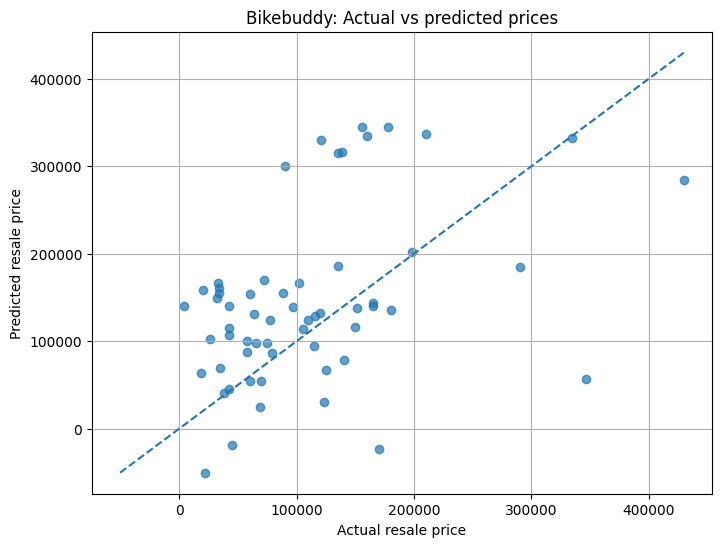

In [54]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
minimum=min(y_test.min(), y_pred.min())
maximum=max(y_test.max(), y_pred.max())
plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)
plt.xlabel("Actual resale price")
plt.ylabel("Predicted resale price")

plt.title("Bikebuddy: Actual vs predicted prices")

plt.grid(True)
plt.show()

In [52]:
print("Actual price range:")
print("Min:",y_test.min())
print("Max:",y_test.max())
print("\nPredicted price range:")
print("Min:", y_pred.min())
print("Max:",y_pred.max())

print("\nRecalculated")
print("mae=",mean_absolute_error(y_test, y_pred))

print("rmse=",np.sqrt(
    mean_squared_error(y_test, y_pred)
))

print("r2=",r2_score(y_test, y_pred))

Actual price range:
Min: 4000
Max: 430000

Predicted price range:
Min: -50571.172193966806
Max: 345282.15691322275

Recalculated
mae= 78586.18811416162
rmse= 102522.94062930194
r2= -0.5003038683401941


In [55]:
from sklearn.dummy import DummyRegressor

In [56]:
dummy_model = DummyRegressor(strategy="mean")

In [58]:
dummy_model.fit(X_train, y_train)
dummy_predictions = dummy_model.predict(X_test)

In [59]:
dummy_mae = mean_absolute_error(y_test, dummy_predictions)

dummy_rmse = np.sqrt(
    mean_squared_error(y_test, dummy_predictions)
)

dummy_r2 = r2_score(y_test, dummy_predictions)

print("DUMMY REGRESSOR RESULTS")
print("-----------------------")

print("MAE:", dummy_mae)
print("RMSE:", dummy_rmse)
print("R2:", dummy_r2)

DUMMY REGRESSOR RESULTS
-----------------------
MAE: 75997.64595103578
RMSE: 93348.40248768215
R2: -0.24380099638007424


In [60]:
print("Number of rows:", df.shape[0])

print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nUnique values:")
print(df.nunique())

Number of rows: 293
Number of columns: 6

Column names:
['Brand', 'Model', 'KM_Driven', 'Year', 'Price', 'Owner']

Data types:
Brand        object
Model        object
KM_Driven     int64
Year          int64
Price         int64
Owner        object
dtype: object

Missing values:
Brand        0
Model        0
KM_Driven    0
Year         0
Price        0
Owner        0
dtype: int64

Unique values:
Brand         16
Model        167
KM_Driven    154
Year          28
Price        179
Owner          4
dtype: int64


In [61]:
print("BRANDS:")
print(df["Brand"].unique())

print("\nOWNER TYPES:")
print(df["Owner"].unique())

print("\nNUMBER OF RECORDS PER BRAND:")
print(df["Brand"].value_counts())

print("\nNUMBER OF RECORDS PER OWNER:")
print(df["Owner"].value_counts())

BRANDS:
['BMW' 'Bajaj' 'Harley Davidson' 'Hero' 'Hero Honda' 'Honda' 'Husqvarna'
 'Jawa' 'KTM' 'Mahindra' 'Revolt' 'Royal Enfield' 'Suzuki' 'TVS' 'Triumph'
 'Yamaha']

OWNER TYPES:
['3rd owner' '1st owner' '2nd owner' '5th owner']

NUMBER OF RECORDS PER BRAND:
Brand
Royal Enfield      60
Yamaha             50
Hero               49
Bajaj              43
Honda              27
KTM                22
Hero Honda         13
TVS                 7
Jawa                5
Suzuki              4
Triumph             4
BMW                 3
Mahindra            2
Harley Davidson     2
Husqvarna           1
Revolt              1
Name: count, dtype: int64

NUMBER OF RECORDS PER OWNER:
Owner
1st owner    248
2nd owner     37
3rd owner      7
5th owner      1
Name: count, dtype: int64


In [62]:
print("PRICE STATISTICS:")
print(df["Price"].describe())

PRICE STATISTICS:
count    2.930000e+02
mean     1.425297e+05
std      2.660448e+05
min      4.000000e+03
25%      4.850000e+04
50%      1.000000e+05
75%      1.600000e+05
max      4.050000e+06
Name: Price, dtype: float64


In [63]:
print("Training features:")
print(X_train.columns.tolist())

print("\nTraining data shape:")
print(X_train.shape)

print("\nTraining target shape:")
print(y_train.shape)

Training features:
['Brand', 'Model', 'KM_Driven', 'Year', 'Owner']

Training data shape:
(234, 5)

Training target shape:
(234,)
